In [1]:
import sys
import os
os.environ['PROJ_DATA'] = "/pscratch/sd/p/plutzner/proj_data"
import xarray as xr
import torch
import torchinfo
import random
import numpy as np
import importlib as imp
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import cartopy.crs as ccrs
import json
import pickle
import gzip
import scipy
from scipy import stats
from cftime import DatetimeNoLeap
from datetime import datetime
from sklearn.metrics import mean_squared_error
#import matplotlib.colors as mcolorsxx

# %load_ext autoreload
# %autoreload 2
import utils
import utils.filemethods as filemethods
import databuilder.data_loader as data_loader
from utils.filemethods import open_data_file
from utils import utils


"""
(1) Open 0101 and 0151 data files containing Z500, PRECT, TS
(2) Check the files for correct magnitudes and variables
(3) Shift 0101 data by -60225 days to 1685-1849
(4) Merge the two datasets into a single dataset with continuous time (1685 - 2014)
(5) Save the merged dataset to a new NetCDF file
(6) Print the shape of the merged dataset
(7) Print the time range of the merged dataset
(8) Print the variable names in the merged dataset

"""
    

'\n(1) Open 0101 and 0151 data files containing Z500, PRECT, TS\n(2) Check the files for correct magnitudes and variables\n(3) Shift 0101 data by -60225 days to 1685-1849\n(4) Merge the two datasets into a single dataset with continuous time (1685 - 2014)\n(5) Save the merged dataset to a new NetCDF file\n(6) Print the shape of the merged dataset\n(7) Print the time range of the merged dataset\n(8) Print the variable names in the merged dataset\n\n'

In [37]:
# def merge_input_files(training_file, val_file, output_file):
#     # Open the training data file
#     ds_train = open_data_file(training_file)
#     ds_train_input = ds_train['x']

#     # Select only 1850-2014 (not 2015)
#     ds_train_input = ds_train_input.sel(time=slice('1850-01-01', '2014-12-31'))

#     # Open the validation data file
#     ds_val = open_data_file(val_file)
#     ds_val_input = ds_val['x']

#     # Shift the time in the test dataset by -60225 days
#     # Datetime no leap is used to avoid leap years in the time series
#     print("Time range of train dataset before shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())
#     ds_train_input['time'] = xr.cftime_range(start='1685-01-01', 
#                                        end='1849-12-31', 
#                                        freq='D',
#                                        calendar='noleap')

#     print("Time range of train dataset after shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())

#     print(f"ds_train_input: {ds_train_input}")

#     # Data is in the form [time, lat, lon, channel] in ['x'], and [time] in ['y']
#     # Merge the two datasets along the time dimension
#     ds_merged_training = xr.merge([ds_train_input, ds_val_input], compat='override')
    
#     print(f"ds_merged_training: {ds_merged_training}")

#     # # Assign the merged time coordinate to the merged dataset
#     # ds_merged_training = ds_merged_training.assign_coords(time=merged_time) ? 

#     # shift and merge target too: 
#     ds_train_target = ds_train['y']
#     ds_val_target = ds_val['y']

#     ds_train_target['time'] = ds_train_input['time']

#     ds_merged_training_target =  xr.merge([ds_train_target, ds_val_target], compat='override')
#     print(f"ds_merged_training_target: {ds_merged_training_target}")
#     print(f"ds_merged_Training_target time: {ds_merged_training_target.time}")

#     # Save the merged dataset to a new pkl file maintingin the ['x'] and ['y'] dictionary structure

#     d_train_new = {
#         'x': ds_merged_training,
#         'y': ds_merged_training_target
#     }
    
# def merge_input_files_efficient_v1(training_file, val_file, output_file):
#     """
#     Memory-efficient version for pickle input files, saves back to pickle format
#     Uses xarray functionality during processing for efficiency
#     """
#     import pickle
    
#     # Create the shifted time coordinate upfront
#     shifted_time = xr.cftime_range(start='1685-01-01', 
#                                   end='1849-12-31', 
#                                   freq='D',
#                                   calendar='noleap')
    
#     # Load pickle files
#     with open(training_file, 'rb') as f:
#         ds_train = pickle.load(f)
    
#     with open(val_file, 'rb') as f:
#         ds_val = pickle.load(f)
    
#     try:
#         # Select and shift training data (1850-2014 -> 1685-1849)
#         ds_train_input = (ds_train['x']
#                          .sel(time=slice('1850-01-01', '2014-12-31'))
#                          .assign_coords(time=shifted_time))
        
#         ds_train_target = (ds_train['y']
#                           .sel(time=slice('1850-01-01', '2014-12-31'))
#                           .assign_coords(time=shifted_time))
        
#         print("Time range of train dataset before shift:", ds_train['x'].sel(time=slice('1850-01-01', '2014-12-31'))['time'].values.min(), "to", ds_train['x'].sel(time=slice('1850-01-01', '2014-12-31'))['time'].values.max())
#         print("Time range of train dataset after shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())
        
#         # Validation data keeps original time coordinates
#         ds_val_input = ds_val['x']
#         ds_val_target = ds_val['y']
        
#         # Concatenate: shifted training data + original validation data
#         ds_merged_input = xr.concat([ds_train_input, ds_val_input], dim='time')
#         ds_merged_target = xr.concat([ds_train_target, ds_val_target], dim='time')
        
#         print(f"ds_merged_input: {ds_merged_input}")
#         print(f"ds_merged_target: {ds_merged_target}")
#         print(f"ds_merged_target time: {ds_merged_target.time}")
        
#         # Create result dictionary (maintaining original structure)
#         d_train_new = {
#             'x': ds_merged_input,
#             'y': ds_merged_target
#         }
        
#         print(f"Final dataset shape - x: {d_train_new['x'].shape}, y: {d_train_new['y'].shape}")
#         print(f"Final time range: {d_train_new['x'].time.values.min()} to {d_train_new['x'].time.values.max()}")
        
#         # Save to pickle with high compression
#         with open(output_file, 'wb') as f:
#             pickle.dump(d_train_new, f, protocol=pickle.HIGHEST_PROTOCOL)
        
#     finally:
#         # Clean up references to help with memory management
#         del ds_train, ds_val
#         import gc
#         gc.collect()



def merge_input_files_efficient_v1(training_file, val_file, output_file):
    """
    Memory-efficient version for pickle input files, saves back to pickle format
    Uses xarray functionality during processing for efficiency
    Includes NaN checking before merging
    """
    import pickle
    import numpy as np
    
    # Create the shifted time coordinate upfront
    shifted_time = xr.cftime_range(start='1685-01-01', 
                                  end='1849-12-31', 
                                  freq='D',
                                  calendar='noleap')
    
    # Load pickle files
    with open(training_file, 'rb') as f:
        ds_train = pickle.load(f)
    
    with open(val_file, 'rb') as f:
        ds_val = pickle.load(f)
    
    try:
        # Select and shift training data (1850-2014 -> 1685-1849)
        ds_train_input = (ds_train['x']
                         .sel(time=slice('1850-01-01', '2014-12-31'))
                         .assign_coords(time=shifted_time))
        
        ds_train_target = (ds_train['y']
                          .sel(time=slice('1850-01-01', '2014-12-31'))
                          .assign_coords(time=shifted_time))
        
        # Validation data keeps original time coordinates
        ds_val_input = ds_val['x']
        ds_val_target = ds_val['y']
        
        print("Time range of train dataset before shift:", ds_train['x'].sel(time=slice('1850-01-01', '2014-12-31'))['time'].values.min(), "to", ds_train['x'].sel(time=slice('1850-01-01', '2014-12-31'))['time'].values.max())
        print("Time range of train dataset after shift:", ds_train_input['time'].values.min(), "to", ds_train_input['time'].values.max())
        
        # Memory-efficient NaN checking
        def check_nans_efficient(data, name):
            """Check for NaNs without loading all data into memory at once"""
            # Use xarray's isnan which is lazy and memory efficient
            nan_mask = data.isnull()
            
            # Count NaNs along time dimension for each spatial point
            nan_count_per_point = nan_mask.sum(dim='time')
            total_nans = nan_count_per_point.sum().values
            
            if total_nans > 0:
                print(f"WARNING: Found {total_nans} NaNs in {name}")
                
                # Check if NaNs are at the beginning (first 26 timesteps)
                if 'time' in data.dims:
                    first_26_nans = nan_mask.isel(time=slice(0, 26)).sum().values
                    print(f"  - NaNs in first 26 timesteps of {name}: {first_26_nans}")
                    
                    # Check pattern across spatial dimensions
                    nan_pattern = nan_mask.sum(dim=['lat', 'lon'] if 'lat' in data.dims else None)
                    if nan_pattern.sum().values > 0:
                        print(f"  - Time steps with NaNs in {name}: {np.where(nan_pattern > 0)[0][:10]}...")  # Show first 10
                
                return True, total_nans
            return False, 0
        
        # Check for NaNs in all datasets before merging
        print("\n=== NaN Check Results ===")
        train_input_has_nans, train_input_nan_count = check_nans_efficient(ds_train_input, "training input")
        train_target_has_nans, train_target_nan_count = check_nans_efficient(ds_train_target, "training target")
        val_input_has_nans, val_input_nan_count = check_nans_efficient(ds_val_input, "validation input")
        val_target_has_nans, val_target_nan_count = check_nans_efficient(ds_val_target, "validation target")
        
        # Optional: Handle NaNs if found
        if any([train_input_has_nans, train_target_has_nans, val_input_has_nans, val_target_has_nans]):
            print(f"\nTotal NaNs found: {train_input_nan_count + train_target_nan_count + val_input_nan_count + val_target_nan_count}")
            
            # Option 1: Remove NaN timesteps (uncomment if desired)
            # print("Removing timesteps with NaNs...")
            # ds_train_input = ds_train_input.dropna(dim='time', how='any')
            # ds_train_target = ds_train_target.dropna(dim='time', how='any')
            # ds_val_input = ds_val_input.dropna(dim='time', how='any')
            # ds_val_target = ds_val_target.dropna(dim='time', how='any')
            
            # Option 2: Fill with interpolation or specific value (uncomment if desired)
            # print("Filling NaNs with interpolation...")
            # ds_train_input = ds_train_input.interpolate_na(dim='time')
            # ds_train_target = ds_train_target.interpolate_na(dim='time')
            # ds_val_input = ds_val_input.interpolate_na(dim='time')
            # ds_val_target = ds_val_target.interpolate_na(dim='time')
            
            # Option 3: Just warn and continue (current behavior)
            print("Proceeding with merge despite NaNs. Consider handling them if this causes issues.")
        else:
            print("No NaNs found in any dataset.")
        
        print("=========================\n")
        
        # Concatenate: shifted training data + original validation data
        ds_merged_input = xr.concat([ds_train_input, ds_val_input], dim='time')
        ds_merged_target = xr.concat([ds_train_target, ds_val_target], dim='time')
        
        print(f"ds_merged_input: {ds_merged_input}")
        print(f"ds_merged_target: {ds_merged_target}")
        print(f"ds_merged_target time: {ds_merged_target.time}")
        
        # Final NaN check on merged data
        print("\n=== Post-Merge NaN Check ===")
        check_nans_efficient(ds_merged_input, "merged input")
        check_nans_efficient(ds_merged_target, "merged target")
        
        # Create result dictionary (maintaining original structure)
        d_train_new = {
            'x': ds_merged_input,
            'y': ds_merged_target
        }
        
        print(f"Final dataset shape - x: {d_train_new['x'].shape}, y: {d_train_new['y'].shape}")
        print(f"Final time range: {d_train_new['x'].time.values.min()} to {d_train_new['x'].time.values.max()}")
        
        # Save to pickle with high compression
        with open(output_file, 'wb') as f:
            pickle.dump(d_train_new, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    finally:
        # Clean up references to help with memory management
        del ds_train, ds_val
        import gc
        gc.collect()


In [ ]:
train_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_train.pkl'
val_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_val.pkl'
test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_test.pkl'

output_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_train_merged.pkl'
merge_input_files_efficient_v1(train_fn, val_fn, output_fn)

In [5]:
test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_test.pkl'

# Split testing dataset into two halves: 
new_validation_dates = [1850, 1931]
new_test_dates = [1932, 2014]

# load testing dataset
original_testing = open_data_file(test_fn)

# Select the new validation and test periods
new_val_input = original_testing['x'].sel(time=slice(f"{new_validation_dates[0]}-01-01", f"{new_validation_dates[1]}-12-31"))
new_val_target = original_testing['y'].sel(time=slice(f"{new_validation_dates[0]}-01-01", f"{new_validation_dates[1]}-12-31"))
new_test_input = original_testing['x'].sel(time=slice(f"{new_test_dates[0]}-01-01", f"{new_test_dates[1]}-12-31"))
new_test_target = original_testing['y'].sel(time=slice(f"{new_test_dates[0]}-01-01", f"{new_test_dates[1]}-12-31"))

# save the new validation and test datasets as pkl
new_val_data = {
    'x': new_val_input,
    'y': new_val_target
}
new_test_data = {
    'x': new_test_input,
    'y': new_test_target
}
new_val_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_val_modified.pkl'
new_test_fn = '/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_test_modified.pkl'

with open(new_val_fn, 'wb') as f:
    pickle.dump(new_val_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(new_test_fn, 'wb') as f:
    pickle.dump(new_test_data, f, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
check_inputs = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp148_d_train.pkl')
# check_inputs['x'] = check_inputs['x'][13:60199, ...]

In [25]:
print(len(check_inputs['x']))

120450


In [26]:
if np.any(np.isnan(check_inputs['x'])):
    print("Input data has nans")
    # print location of nans
    nan_locations = np.where(np.isnan(check_inputs['x']))
    print(nan_locations)

Input data has nans
(array([    0,     0,     0, ..., 60237, 60237, 60237]), array([  0,   0,   0, ..., 179, 179, 179]), array([  0,   0,   1, ..., 358, 359, 359]), array([0, 1, 0, ..., 1, 0, 1]))


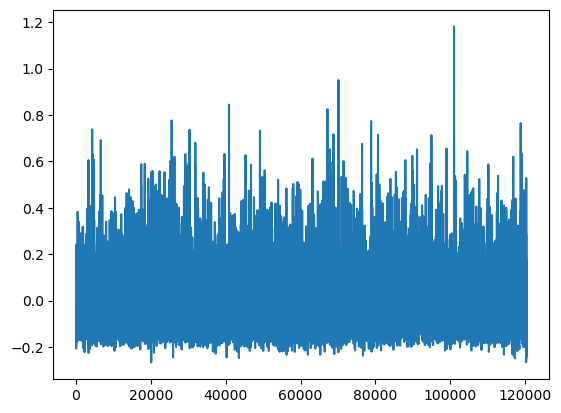

In [27]:
plt.figure()
plt.plot(check_inputs['x'][:, 0, 179, 0])

In [74]:
# p_conv.PRECT.sel(lat = 40.5, lon = 100.5).plot()
exp148_input = check_inputs['x']
print(exp148_input)
exp148_input_day = exp148_input[60180, :, :, 0]

plt.figure()
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
cf1 = ax.pcolormesh(exp148_input_day.lon, exp148_input_day.lat, exp148_input_day, cmap='Purples', transform=ccrs.PlateCarree())#, vmax=p_converted.max(), vmin=-1 * p_converted.max())
ax.coastlines()
# select only north pacific region
ax.set_extent([-180, -100, 20, 60], crs=ccrs.PlateCarree())
ax.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

cbar1 = fig.colorbar(cf1, cmap='PuOr', ax=ax, orientation='vertical', fraction=0.01, pad=0.03)
cbar1.set_label('Precipitation (mm/day)', fontsize=12)

<xarray.DataArray 'PRECT' (time: 60172, lat: 180, lon: 360, channel: 2)> Size: 62GB
array([[[[-0.1182608 ,  1.538293  ],
         [-0.11804939,  1.54019892],
         [-0.11783927,  1.54208851],
         ...,
         [-0.11890077,  1.53250921],
         [-0.11868669,  1.534446  ],
         [-0.1184733 ,  1.53637528]],

        [[-0.09934819,  1.83527637],
         [-0.09870054,  1.86073959],
         [-0.09806316,  1.88599658],
         ...,
         [-0.10134741,  1.75809097],
         [-0.10067216,  1.783903  ],
         [-0.10000557,  1.80964649]],

        [[-0.08090197,  2.27344441],
         [-0.07929344,  2.35215735],
         [-0.0776959 ,  2.4302609 ],
         ...,
...
         ...,
         [-0.26119217,  1.60444808],
         [-0.26295808,  1.59167588],
         [-0.26481517,  1.57909012]],

        [[-0.29664854,  1.95381618],
         [-0.2982819 ,  1.94763279],
         [-0.29991288,  1.94165957],
         ...,
         [-0.29173851,  1.97358215],
         [-0.29337641,

IndexError: index 60180 is out of bounds for axis 0 with size 60172

In [34]:
orig_inputs = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/presaved/exp140_d_val.pkl')

In [36]:
if np.any(np.isnan(orig_inputs['x'][26:, ...])):
    print("Input data has nans")
    # print location of nans
    nan_locations = np.where(np.isnan(orig_inputs['x']))
    print(nan_locations)

In [33]:
print(orig_inputs['x'][26:30010, ...])

<xarray.DataArray 'PRECT' (time: 29984, lat: 180, lon: 360, channel: 2)> Size: 31GB
array([[[[ 3.44575900e-02, -5.25041163e-01],
         [ 3.45215954e-02, -5.16685486e-01],
         [ 3.45898557e-02, -5.08327007e-01],
         ...,
         [ 3.42917038e-02, -5.50010502e-01],
         [ 3.43426070e-02, -5.41712046e-01],
         [ 3.43979141e-02, -5.33383310e-01]],

        [[ 5.55676583e-04, -5.68583965e-01],
         [ 1.04556797e-03, -5.33849180e-01],
         [ 1.55933361e-03, -4.99121517e-01],
         ...,
         [-7.62055615e-04, -6.72417760e-01],
         [-3.48998190e-04, -6.37908638e-01],
         [ 9.05336291e-05, -6.03282452e-01]],

        [[-4.32378677e-02, -4.18658167e-01],
         [-4.15652198e-02, -3.39196622e-01],
         [-3.98872509e-02, -2.60346651e-01],
         ...,
...
         ...,
         [-2.25910956e-01, -1.09150326e+00],
         [-2.23764032e-01, -1.14526248e+00],
         [-2.21553131e-01, -1.19888628e+00]],

        [[-1.37166510e-01, -1.45168459e+